In [30]:
import numpy as np
import matplotlib.pyplot as plt 
import allantools as at
from allantools import noise
import sys
import pandas as pd

In [31]:
def allanover(y,yerr,t,types):
    #calculate some parameters
    n = np.arange(3,1+round(len(y)//3),1)
    tau0 = np.mean(np.diff(t))
    step = tau0

    allanvar = []
    tau = []
    for jj in range(len(n)):
         nconstraint = 2 #define constraint of number of data point in window
         #sliding windows
         left = min(t)#0
         right = min(t) + n[jj]*tau0#n[jj]
         ytemp = []
         temp = []
         #while right <= len(y):
             #ytemp.append(np.mean(y[left:right]))
         while right <= max(t):
             temp.append(len(y[(t>=left) & (t<=right)]))
             if len(y[(t>=left) & (t<=right)]) == 0:
                 ytemp.append(np.average(y[(t>=left) & (t<=right)]))
             else:
                 if types == 1: #types = 1 for weighted average
                     weight = 1/yerr[(t>=left) & (t<=right)]**2
                     ytemp.append(np.average(y[(t>=left) & (t<=right)],weights=weight))
                 else:
                     ytemp.append(np.average(y[(t>=left) & (t<=right)]))
             left = left + step
             right = right + step
         temp = np.array(temp)
         ytemp = np.array(ytemp)
         M = len(ytemp)
         #D = np.count_nonzero(np.isnan(ytemp))
         D = len(ytemp[temp<=nconstraint])
         print(jj,len(n), M, D)
         
         #discard the window with too few data
         #ytemp = np.array(ytemp)[~np.isnan(ytemp)].tolist()
         ytemp = ytemp[temp>nconstraint]
         
         #calculate Allan variance
         ysum2 = []
         i = 0
         while i < M-2*n[jj]+1-D:
             j = i
             ysum = []
             while j <= i+n[jj]-1:
                 ysum.append(ytemp[j+n[jj]]-ytemp[j])
                 j = j+1
             ysum2.append(0.5*(np.sum(ysum)/n[jj])**2)
             i = i+1
         allanvar.append(np.sum(ysum2)/(M-2*n[jj]+1-D))
         tau.append(tau0*n[jj])

    allanstd = np.sqrt(allanvar)

    return tau,allanvar,allanstd

In [32]:
def process_data(data_txt):
    # Read data
    cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']
    cols_widths = [(0,9),(9,26),(27,46),(47,56),(57,66),(67,74),(75,79)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=4, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna()    
    
    # Convert from mas to microas
    df_new['R.A. (micas)'] = df_new['R.A. (mas)']*1000
    df_new['Dec. (micas)'] = df_new['Dec. (mas)']*1000
    df_new['Err. R.A. (micas)'] = df_new['Err. R.A. (mas)']*1000
    df_new['Err. Dec. (micas)'] = df_new['Err. Dec. (mas)']*1000
    
    # Convert from mas to degrees to radian
    df_new['Dec. (rad)'] = (df_new['Dec. (mas)']/(3600*1000)).apply(np.deg2rad)
    
    # Calculate RA*cos(dec) column
    
    df_new['RAcosDEC'] = df_new['R.A. (micas)']*np.cos(df_new['Dec. (rad)'])
    
    # Calculate Besselian Year column
    df_new['BY'] = 2000-(51544.333981-df_new['MJD'])/365.242198781
    
    return df_new

In [33]:
df = process_data('1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,-1909.625187,-1887.001224,1291.2,741.7,-9.148440e-09,-1909.625187,1984.147297
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,-1554.359283,-2305.601981,1203.2,1136.2,-1.117787e-08,-1554.359283,1984.160968
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,51.039535,1460.397601,706.9,618.2,7.080207e-09,51.039535,1984.174638
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-5738.531828,890.999991,2531.6,1107.3,4.319690e-09,-5738.531828,1984.188369
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2972.004239,696.600000,648.4,630.7,3.377212e-09,-2972.004239,1984.448484


In [44]:
df_sel = df[df['BY'] < 2015]
len(df_sel)

2233

In [45]:
dec = df_sel['Dec. (mas)']
errdec = df_sel['Err. Dec. (mas)']
ra_n = df_sel['R.A. (mas)']
errra_n = df_sel['Err. R.A. (mas)']
mjd = df_sel['MJD']
by = df_sel['BY']

In [46]:
#convert from mas to microas
dec     = 1000*dec
errdec  = 1000*errdec
ra_n    = 1000*ra_n
errra_n = 1000*errra_n



In [ ]:
tau_dec,allanvar_dec,allanstd_dec = allanover(dec,errdec,by,1)

0 742 2229 924
1 742 2228 515
2 742 2227 373
3 742 2226 278
4 742 2225 217
5 742 2224 176
6 742 2223 147
7 742 2222 124
8 742 2221 106
9 742 2220 89
10 742 2219 76
11 742 2218 64
12 742 2217 52
13 742 2216 44
14 742 2215 33
15 742 2214 24
16 742 2213 17
17 742 2212 11
18 742 2211 6
19 742 2210 3
20 742 2209 2
21 742 2208 1
22 742 2207 0
23 742 2206 0
24 742 2205 0
25 742 2204 0
26 742 2203 0
27 742 2202 0
28 742 2201 0
29 742 2200 0
30 742 2199 0
31 742 2198 0
32 742 2197 0
33 742 2196 0
34 742 2195 0
35 742 2194 0
36 742 2193 0
37 742 2192 0
38 742 2191 0
39 742 2190 0
40 742 2189 0
41 742 2188 0
42 742 2187 0
43 742 2186 0
44 742 2185 0
45 742 2184 0
46 742 2183 0
47 742 2182 0
48 742 2181 0
49 742 2180 0
50 742 2179 0
51 742 2178 0
52 742 2177 0
53 742 2176 0
54 742 2175 0
55 742 2174 0
56 742 2173 0
57 742 2172 0
58 742 2171 0
59 742 2170 0
60 742 2169 0
61 742 2168 0
62 742 2167 0
63 742 2166 0
64 742 2165 0
65 742 2164 0
66 742 2163 0
67 742 2162 0
68 742 2161 0
69 742 2160 0
70 

In [37]:
fs = 12
color = 'black'
ymin = 1
ymax = 10000

No handles with labels found to put in legend.


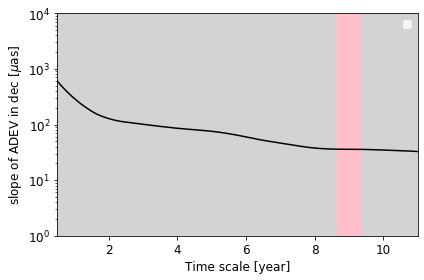

In [38]:
plt.figure()
ax = plt.gca()
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
plt.plot(tau_dec,allanstd_dec,color=color)
plt.fill_between(tau_dec[1:], ymin,ymax, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec[1:], ymin,ymax, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec[1:], ymin,ymax, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
plt.yscale('log')
#plt.xscale('log')
ax.xaxis.set_tick_params(labelsize=fs)
ax.yaxis.set_tick_params(labelsize=fs)
plt.xlabel('Time scale [year]', fontsize=fs)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=fs)
plt.legend(fontsize=fs)
plt.ylim(ymin,ymax)
plt.xlim(0.5,11)
plt.tight_layout()

In [28]:
tau_dec

[0.04355147774249052,
 0.058068636989987356,
 0.0725857962374842,
 0.08710295548498104,
 0.10162011473247787,
 0.11613727397997471,
 0.13065443322747156,
 0.1451715924749684,
 0.15968875172246522,
 0.17420591096996207,
 0.1887230702174589,
 0.20324022946495574,
 0.2177573887124526,
 0.23227454795994942,
 0.24679170720744625,
 0.2613088664549431,
 0.2758260257024399,
 0.2903431849499368,
 0.30486034419743363,
 0.31937750344493043,
 0.3338946626924273,
 0.34841182193992415,
 0.36292898118742095,
 0.3774461404349178,
 0.39196329968241467,
 0.40648045892991147,
 0.42099761817740833,
 0.4355147774249052,
 0.450031936672402,
 0.46454909591989885,
 0.4790662551673957,
 0.4935834144148925,
 0.5081005736623894,
 0.5226177329098862,
 0.5371348921573831,
 0.5516520514048798,
 0.5661692106523767,
 0.5806863698998735,
 0.5952035291473704,
 0.6097206883948673,
 0.6242378476423641,
 0.6387550068898609,
 0.6532721661373577,
 0.6677893253848546,
 0.6823064846323514,
 0.6968236438798483,
 0.711340803127

In [26]:
allanstd_dec

array([ 415.65625383,  387.47389532,  379.00098395,  362.44495135,
        367.02743637,  387.99826115,  433.80281753,  480.2425562 ,
        513.61573556,  546.12242973,  581.61201392,  619.08287271,
        624.89346923,  713.98702529,  798.90393048,  878.48455938,
        978.71804073, 1025.62511657,  994.34411322,  967.05092812,
        940.00242398,  913.43994555,  892.29666268,  851.24632377,
        809.95556045,  767.92226408,  726.44911896,  685.97695086,
        660.36142574,  636.73595745,  620.84091294,  606.71850658,
        592.28410923,  579.32707086,  566.5326616 ,  552.04718661,
        537.55785953,  525.1794945 ,  511.93696885,  500.21982662,
        489.15254703,  477.40879412,  466.84881582,  456.87906549,
        447.17463512,  438.15201992,  429.61098267,  421.20622015,
        411.78878742,  402.88991175,  393.97333719,  385.69639405,
        378.06903217,  370.76272757,  363.32704868,  356.20040404,
        349.20326534,  342.55146567,  335.97257058,  329.73203

In [27]:
len(allanstd_dec)

907

In [ ]:
tau_ra,allanvar_ra,allanstd_ra = allanover(ra_n,errra_n,by,1)


In [39]:
def readdata(dataname_dec,dataname_ra,datatype):
    
    if datatype == 1:
        data_dec = np.genfromtxt(dataname_dec)
        data_ra = np.genfromtxt(dataname_ra)

        mjd = data_dec[:,0]
        by  = mjdtoby(mjd)
        dec = data_dec[:,1]
        ra  = data_ra[:,1]
        errdec = data_dec[:,2]
        errra  = data_ra[:,2]

        #convert ra
        ra = ra*15 #convert R.A. from milisecond to mas
        errra = errra*15  #convert R.A. from milisecond to mas

        #calculate R.A.*cos(dec) and its error propagation
        decr = np.deg2rad(dec/1000/3600); #declination in radian
        ra_n = ra*np.cos(decr);
        dra_ndra = np.cos(decr);
        dra_nddec = -ra*np.sin(decr);
        errra_n = np.sqrt(((dra_ndra)**2)*(errra**2) + ((dra_nddec)**2)*(errdec**2));

    elif datatype == 2:
        data_dec = np.genfromtxt(dataname_dec,comments='%')
        data_ra = np.genfromtxt(dataname_ra,comments='%')

        mjd = data_dec[:,0]
        by  = mjdtoby(mjd)
        dec = data_dec[:,2]
        ra  = data_ra[:,1]
        errdec = data_dec[:,4]
        errra  = data_ra[:,3]


        #calculate R.A.*cos(dec) and its error propagation
        decr = np.deg2rad(dec/1000/3600); #declination in radian
        ra_n = ra*np.cos(decr);
        errra_n = errra
        
    return mjd,by,dec,ra_n,errdec,errra_n

In [40]:
dataname_dec = '1803+784_dem.txt'


In [42]:
mjd,by,dec,ra_n,errdec,errra_n = readdata(dataname_dec,dataname_ra,datatype)


ValueError: Some errors were detected !
    Line #2336 (got 6 columns instead of 7)
    Line #2415 (got 5 columns instead of 7)